# STEP 1 — 球面地球（Skolnik）での直達・反射パスとパス差 ΔR

**目的**  
アンテナ高さ $h_1$、目標高さ $h_2$、直達スラントレンジ $R_d$（Skolnik の定義）から、
- 反射路長 $R_1 + R_2$ を計算し、
- パス差 $\Delta R = (R_1 + R_2) - R_d$ を求める。

**前提**（P.452 からの引用方針）  
- 有効地球半径法：$a_e = k\,a$（標準は $k=4/3$, $a \approx 6{,}371\,\text{km}$）。
- 半径 $r_1=a_e+h_1$, $r_2=a_e+h_2$。
- 反射点の弧長 $G_1$ は Skolnik 2nd ed. の Fishback 解（式(2.50)–(2.52)）を用いる。


In [100]:
# ==== STEP1 関数の定義（再掲） ====
import math
import numpy as np

def spherical_two_ray_lengths(h1, h2, Rd, a=6_371_000.0, k=4.0/3.0, *, tol=1e-12):
    """
    球面地球（有効地球半径 a_e = k*a）での直達/反射路長と ΔR を返す。
    戻り値: dict {"L_los","R1","R2","L_refl","deltaR","G","G1","G2","ae"}
    単位は [m]。
    参照: Skolnik, Radar Handbook 2nd ed., Eqs. (2.49)–(2.53)
    """
    ae = float(k) * float(a)
    r1 = ae + float(h1)
    r2 = ae + float(h2)
    L_los = float(Rd)

    # 直達の中心角
    cos_th = (r1*r1 + r2*r2 - L_los*L_los) / (2.0*r1*r2)
    if cos_th < -1.0 - tol or cos_th > 1.0 + tol:
        # 非物理域（見通し外など）は NaN を返す
        return {
            "L_los": np.nan, "R1": np.nan, "R2": np.nan, "L_refl": np.nan, "deltaR": np.nan,
            "G": np.nan, "G1": np.nan, "G2": np.nan, "ae": ae
        }
    cos_th = max(-1.0, min(1.0, cos_th))
    theta = math.acos(cos_th)
    G = ae * theta

    # Fishback 解
    p = (2.0/math.sqrt(3.0)) * math.sqrt(ae*(h1 + h2) + (G*0.5)**2)
    if p == 0.0:
        G1 = G * 0.5
    else:
        arg = (2.0 * ae * G * (h2 - h1)) / (p**3)
        arg = max(-1.0, min(1.0, arg))
        sigma = math.asin(arg)
        G1 = (G * 0.5) - p * math.sin(sigma/3.0)
    G2 = G - G1

    # 路長
    th1 = G1 / ae
    th2 = G2 / ae
    R1 = math.sqrt((ae + h1)**2 + ae**2 - 2.0*ae*(ae + h1)*math.cos(th1))
    R2 = math.sqrt((ae + h2)**2 + ae**2 - 2.0*ae*(ae + h2)*math.cos(th2))
    L_refl = R1 + R2
    deltaR = L_refl - L_los

    return {
        "L_los": L_los, "R1": R1, "R2": R2, "L_refl": L_refl, "deltaR": deltaR,
        "G": G, "G1": G1, "G2": G2, "ae": ae
    }

def grazing_angle_from_geometry(res, h1, h2):
    """
    反射点でのグレージング角 ψ（地表からの仰角, [rad]）を幾何から計算。
    """
    ae = res["ae"]
    if not np.isfinite(ae):
        return np.nan
    r1 = ae + float(h1)
    R1 = res["R1"]
    if not np.isfinite(R1):
        return np.nan
    theta1 = res["G1"] / ae
    # cosψ = (r1/R1) sinθ1 → ψ = asin(sinψ) だが、数値安定のため cosψ を [0,1] にクリップ
    cos_psi = (r1 / R1) * math.sin(theta1)
    cos_psi = max(0.0, min(1.0, cos_psi))
    sin_psi = math.sqrt(max(0.0, 1.0 - cos_psi*cos_psi))
    return math.asin(sin_psi)

def elevations_from_geometry(res, h1, h2):
    """
    送信点から見た直達・反射の仰角（水平=0, 上向き正, [rad]）を返す。
    直達: sinα = (r2/Rd) sinθ,  ε = π/2 - α
    反射: sinα = (ae/R1) sinθ1, ε = π/2 - α
    """
    ae = res["ae"]
    if not np.isfinite(ae):
        return (np.nan, np.nan)
    r1 = ae + float(h1)
    r2 = ae + float(h2)
    Rd = res["L_los"]
    R1 = res["R1"]
    theta = res["G"] / ae
    theta1 = res["G1"] / ae
    if not all(np.isfinite(x) for x in [r1, r2, Rd, R1, theta, theta1]):
        return (np.nan, np.nan)

    s1 = (r2 / Rd) * math.sin(theta)
    s1 = max(-1.0, min(1.0, s1))
    alpha_dir = math.asin(s1)
    eps_dir = math.pi/2 - alpha_dir

    s2 = (ae / R1) * math.sin(theta1)
    s2 = max(-1.0, min(1.0, s2))
    alpha_refl = math.asin(s2)
    eps_refl = math.pi/2 - alpha_refl

    return (eps_dir, eps_refl)


# STEP 2 — 経路差のみを位相に変換して複素数合成（式(2.55)は不使用）

- 波長 $\lambda = c/f$
- 位相差 $\phi = \dfrac{2\pi}{\lambda}\,\Delta R$
- 直達を 1、反射の振幅比は $\rho$（既定 1）として、
  $E_{\text{tot}} = 1 + \rho\,e^{-j\phi}$
- 返り値：複素合成の実部・虚部・振幅 $|E|$・レベル[dB]


# 地面の複素反射係数（ITU-R ベース）

$$
\tilde{\varepsilon}_r \;=\; \varepsilon_r \;-\; j\,60\,\sigma\,\lambda,\qquad \lambda=\frac{c}{f}.
$$

**水平偏波（H, TE）**
$$
\Gamma_{\mathrm{h}}(\psi)
= \frac{\sin\psi - \sqrt{\tilde{\varepsilon}_r - \cos^2\psi}}
       {\sin\psi + \sqrt{\tilde{\varepsilon}_r - \cos^2\psi}}
$$

**垂直偏波（V, TM）**
$$
\Gamma_{\mathrm{v}}(\psi)
= \frac{\tilde{\varepsilon}_r \sin\psi - \sqrt{\tilde{\varepsilon}_r - \cos^2\psi}}
       {\tilde{\varepsilon}_r \sin\psi + \sqrt{\tilde{\varepsilon}_r - \cos^2\psi}}
$$

> 参考：ITU-R P.1411（Annex の二波モデル）、ITU-R P.452（LoS 反射の扱い）。  
> 地面の物性（$\varepsilon_r,\ \sigma$）代表値は ITU-R P.527。


In [101]:
import numpy as np, math, cmath

# ITU 便宜表記の複素比誘電率と Fresnel Γ
def complex_eps_itu(eps_r: float, sigma: float, f_hz: float) -> complex:
    c = 299_792_458.0; lam = c / f_hz
    return complex(eps_r, 0.0) - 1j * (60.0 * sigma * lam)

def fresnel_gamma(psi_rad: float, eps_r: float, sigma: float, f_hz: float, pol: str="H") -> complex:
    eps_c = complex_eps_itu(eps_r, sigma, f_hz)
    s = math.sin(psi_rad); c = math.cos(psi_rad)
    root = cmath.sqrt(eps_c - c*c)
    return (s - root)/(s + root) if pol.upper()=="H" else (eps_c*s - root)/(eps_c*s + root)


# 二波合成（複素AFとΓを使用）
def combine_AF_and_gamma(deltaR: float, f_hz: float, F_dir: complex, F_refl: complex, gamma: complex) -> dict:
    c = 299_792_458.0; lam = c / f_hz
    phi = 2.0*np.pi*(deltaR/lam)
    Etot = F_dir + F_refl * gamma * cmath.exp(-1j*phi)
    Eabs = abs(Etot)
    level_dB = 20.0*np.log10(Eabs) if Eabs>0 else float("-inf")
    return {"lambda": lam, "phi_path": phi, "Etot": Etot, "Eabs": Eabs, "level_dB": level_dB}


# リニア等間隔アレイのアレイファクタ（IEICE）

素子数 $N$、素子間隔 $d$、主ビーム方向 $\theta_0$ のとき、アレイファクタ

$$
F(u) \;=\; \frac{\sin\!\left(\tfrac{N u}{2}\right)}{N \,\sin\!\left(\tfrac{u}{2}\right)},
\qquad
u \;=\; k_0 d \bigl(\sin\theta - \sin\theta_0\bigr),\quad k_0=\frac{2\pi}{\lambda}.
$$

- 正規化済み（$|F(0)|=1$、主ビーム近傍で最大1）。
- **振幅**：$|F(u)|$、（dB表示は $20\log_{10}|F(u)|$）
- **位相**：$\arg F(u)$（アンラップして連続化するのが見やすい）

出典：電子情報通信学会ハンドブック（IEICE） 第4群2編7章, (7・3), (7・4)。


# 線形アレイファクタの式とその厳密性

## 1. 基本式の導出と線形位相項の根拠

等間隔・等振幅・等位相励振の線形アレイ（素子数 \(N\)、素子間隔 \(d\)）の観測角 $(\theta)$ における複素アレイファクタは

$$
F_{\mathrm{full}}(u) = \frac{1}{N} \sum_{n=0}^{N-1} e^{j n u}
$$

で表される。ここで  

$$
u = k_0 d \,(\sin\theta - \sin\theta_0),\quad k_0 = \frac{2\pi}{\lambda}
$$

であり、$(\theta_0)$ は主ビーム方向。

この和は等比級数の公式を使って厳密に評価できる：

$$
\sum_{n=0}^{N-1} e^{j n u}
= e^{j \frac{(N-1)u}{2}} \cdot \frac{\sin\left(\frac{N u}{2}\right)}{\sin\left(\frac{u}{2}\right)}.
$$

よって

$$
\boxed{
F_{\mathrm{full}}(u) =
e^{j \frac{(N-1)u}{2}} \cdot
\frac{\sin\left(\frac{N u}{2}\right)}{N \sin\left(\frac{u}{2}\right)}
}
$$

- **第1因子** $(e^{j\frac{(N-1)u}{2}})$：素子列の位相中心が中央にあることを反映する**線形位相**。観測角の変化に対して位相が直線的に変化する。
- **第2因子**：**振幅項**（Dirichlet kernel の正規化）。

**エビデンス**：この式は  
- IEICEハンドブック 第4群2編7章 式(7・1)～(7・4)  
- Balanis, *Antenna Theory*, Sec. 6（Array Factor）  
- Stutzman & Thiele, *Antenna Theory and Design*, Chap. 4  
などに同様の導出が記載されている。

---

## 2. sinc関数による表現と厳密性

$$
\operatorname{sinc}(x) = \frac{\sin x}{x},\quad \operatorname{sinc}(0) \stackrel{\mathrm{def}}{=} 1
$$

この定義を使えば

$$
\frac{\sin\left(\frac{N u}{2}\right)}{N \sin\left(\frac{u}{2}\right)}
= \frac{\frac{\sin\left(\frac{N u}{2}\right)}{\frac{N u}{2}}}
       {\frac{\sin\left(\frac{u}{2}\right)}{\frac{u}{2}}}
= \frac{\operatorname{sinc}\left(\frac{N u}{2}\right)}
       {\operatorname{sinc}\left(\frac{u}{2}\right)}
$$

となり、**完全な恒等変形**である。近似ではない。

NumPy の `np.sinc` は  

$$
\texttt{np.sinc}(x) = \frac{\sin(\pi x)}{\pi x}
$$

という規約のため、引数を $((\cdot)/\pi)$ に変換すれば同じ結果が得られる。

例：
```python
num = np.sinc((N*u/2)/np.pi)
den = np.sinc((u/2)/np.pi)
AF  = np.exp(1j*(N-1)*u/2) * num/den


In [102]:

# 複素アレイファクタ（sinc で安定化）：F_full(θ)
def array_factor_full(theta_rad: float, N: int, d_lambda: float, theta0_rad: float) -> complex:
    u = 2.0*np.pi*d_lambda * (np.sin(theta_rad) - np.sin(theta0_rad))  # k0 d (sinθ - sinθ0)
    num = np.sinc((N*u/2.0)/np.pi)      # = sin(Nu/2)/(Nu/2)
    den = np.sinc((u/2.0)/np.pi)        # = sin(u/2)/(u/2)
    amp = num / den                     # 実数（正規化振幅）
    phi = 0.5*(N-1)*u                   # 線形位相
    return amp * np.exp(1j*phi)

In [103]:
# --- 幾何/地球 ---
h1 = 100.0         # [m]
h2 = 10_000.0      # [m]
a  = 6_371_000.0   # [m]
k  = 4.0/3.0       # [-]

# --- 伝搬/反射 ---
freq  = 1.5e9      # [Hz]
pol   = "V"        # "H" or "V"
eps_r = 15.0       # 地面の比誘電率（例）
sigma = 0.005      # [S/m]

# --- アレイファクタ ---
N          = 16        # 素子数
d_lambda   = 0.5       # 素子間隔 d/λ
theta0_deg = 5       # 主ビーム方向 [deg]
theta0_rad = np.deg2rad(theta0_deg)

# --- スラントレンジ掃引 ---
Rd_start_km = 10.0
Rd_end_km   = 300.0
Rd_step_km  = 1.0
Rd_km = np.arange(Rd_start_km, Rd_end_km + 1e-9, Rd_step_km)
Rd_m  = 1000.0 * Rd_km


## STEP1: 二経路間の距離差 ΔR の計算
地球曲率を考慮した二経路モデル（直達波と地面反射波）の経路差は、球面幾何から次式で求められる。

$$
R_1 = \sqrt{(a+kR_e)^2 + h_1^2 - 2(a+kR_e)(a+kR_e-h_2)\cos\theta}
$$

$$
R_2 = \sqrt{(a+kR_e)^2 + h_2^2 - 2(a+kR_e)(a+kR_e-h_1)\cos\theta}
$$

経路差は
$$
\Delta R = R_2 - R_1
$$
ここで $a$ は地球半径、$k$ は有効地球半径係数（通常 $4/3$）。


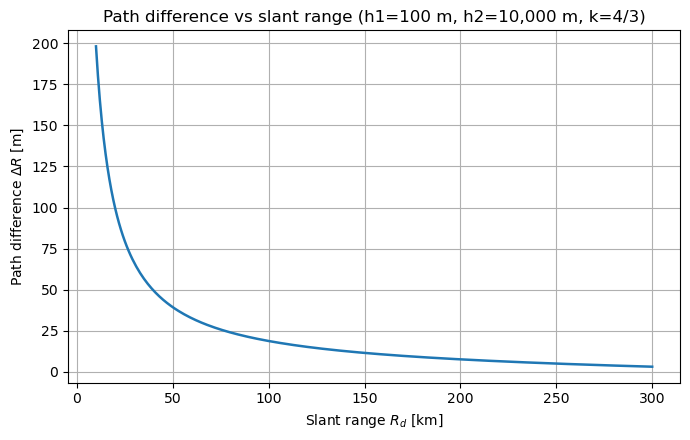

In [104]:
import matplotlib.pyplot as plt
deltaR_m = np.full_like(Rd_m, np.nan, dtype=float)
psi_rad  = np.full_like(Rd_m, np.nan, dtype=float)
eps_dir  = np.full_like(Rd_m, np.nan, dtype=float)
eps_refl = np.full_like(Rd_m, np.nan, dtype=float)

for i, Rd in enumerate(Rd_m):
    res = spherical_two_ray_lengths(h1=h1, h2=h2, Rd=Rd, a=a, k=k)
    if not np.isfinite(res["deltaR"]):
        continue
    deltaR_m[i] = res["deltaR"]
    psi_rad[i]  = grazing_angle_from_geometry(res, h1, h2)
    ed, er = elevations_from_geometry(res, h1, h2)
    eps_dir[i], eps_refl[i] = ed, er


    # === プロット（ΔR vs Rd） ===
plt.figure(figsize=(7, 4.5))
plt.plot(Rd_km, deltaR_m, lw=1.8)
plt.xlabel("Slant range $R_d$ [km]")
plt.ylabel("Path difference $\\Delta R$ [m]")
plt.title("Path difference vs slant range (h1=100 m, h2=10,000 m, k=4/3)")
plt.grid(True)
plt.tight_layout()
plt.show()


## STEP2: 経路差と複素反射係数による合成
地面反射波の複素反射係数 $\Gamma(\theta)$ はフレネル反射係数で与えられる。

垂直偏波の場合：
$$
\Gamma_\perp(\theta) = \frac{\cos\theta - \sqrt{\varepsilon_r - \sin^2\theta}}{\cos\theta + \sqrt{\varepsilon_r - \sin^2\theta}}
$$

水平偏波の場合：
$$
\Gamma_\parallel(\theta) = \frac{\varepsilon_r\cos\theta - \sqrt{\varepsilon_r - \sin^2\theta}}{\varepsilon_r\cos\theta + \sqrt{\varepsilon_r - \sin^2\theta}}
$$

ここで $\varepsilon_r$ は地面の複素比誘電率。
反射波と直達波の合成は、経路差に対応する位相差
$$
\phi = \frac{2\pi \Delta R}{\lambda}
$$
を用い、複素ベクトル和で計算する。


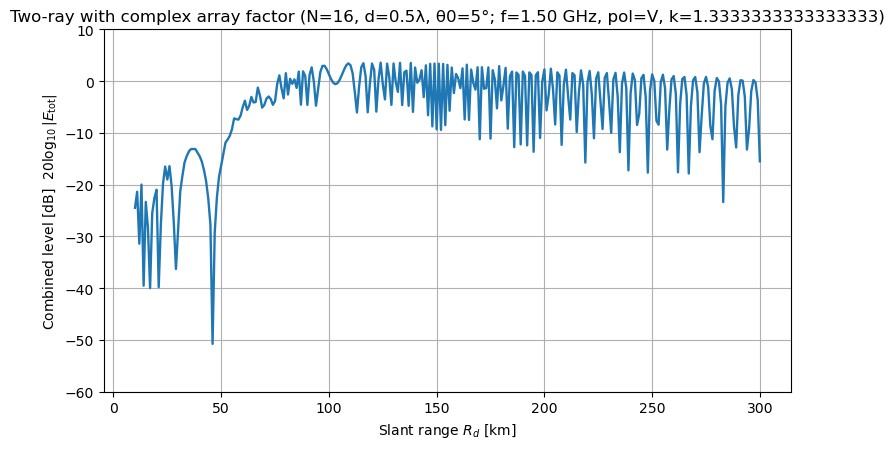

In [105]:
import matplotlib.pyplot as plt

level_dB = np.full_like(Rd_m, np.nan, dtype=float)
Gm_mag_db_arr = np.full_like(Rd_m, np.nan, dtype=float)  # ← 追加：|Γ|[dB] 用
Gm_mag_arr = np.full_like(Rd_m, np.nan, dtype=float)  # ← 追加：|Γ|[dB] 用
Gm_ph_deg_arr = np.full_like(Rd_m, np.nan, dtype=float)  # ← 追加：∠Γ[deg] 用

for i, (dR, psi, ed, er) in enumerate(zip(deltaR_m, psi_rad, eps_dir, eps_refl)):
    if not all(np.isfinite(x) for x in [dR, psi, ed, er]):
        continue
    # 複素アレイファクタ（直達/反射）
    Fd = array_factor_full(ed, N=N, d_lambda=d_lambda, theta0_rad=theta0_rad)
    Fr = array_factor_full(er, N=N, d_lambda=d_lambda, theta0_rad=theta0_rad)
    # Fresnel 反射係数
    Gm = fresnel_gamma(psi, eps_r=eps_r, sigma=sigma, f_hz=freq, pol=pol)
    # ← 追加：Γの振幅[dB]と位相[deg]を保存
    # Gm_mag_db_arr[i] = 20.0*np.log10(max(np.abs(Gm), 1e-12))
    Gm_mag_arr[i] = (max(np.abs(Gm), 1e-12))
    Gm_ph_deg_arr[i] = np.degrees(np.angle(Gm))

    # 合成
    out = combine_AF_and_gamma(deltaR=dR, f_hz=freq, F_dir=Fd, F_refl=Fr, gamma=Gm)
    level_dB[i] = out["level_dB"]

plt.figure(figsize=(7.8,4.6))
plt.plot(Rd_km, level_dB, lw=1.7)
plt.xlabel("Slant range $R_d$ [km]")
plt.ylabel("Combined level [dB]  $20\\log_{10}|E_{\\rm tot}|$")
plt.ylim(-60, 10)  # y軸の範囲を設定
plt.title(f"Two-ray with complex array factor (N={N}, d={d_lambda}λ, θ0={theta0_deg}°; f={freq/1e9:.2f} GHz, pol={pol}, k={k})")
plt.grid(True); plt.tight_layout(); plt.show()


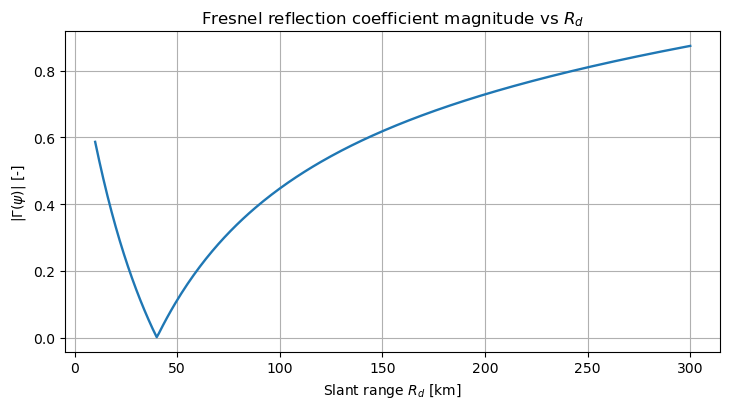

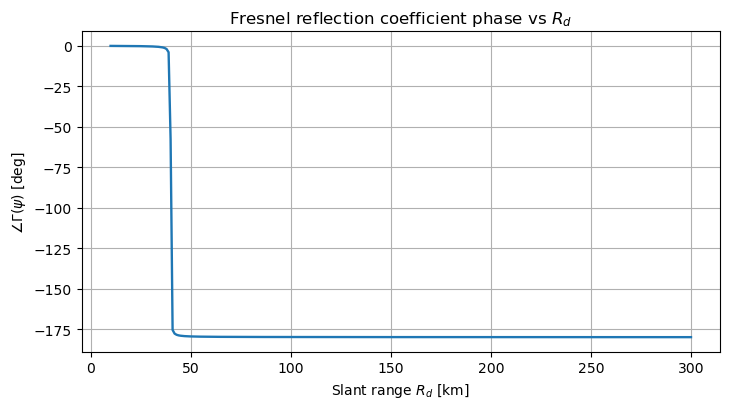

In [106]:
# 追加：Γ(psi) の振幅[dB] vs R_d
plt.figure(figsize=(7.4,4.2))
# plt.plot(Rd_km, Gm_mag_db_arr, lw=1.7)
plt.plot(Rd_km, Gm_mag_arr, lw=1.7)
plt.xlabel("Slant range $R_d$ [km]")   # メートルにしたい場合は Rd_m を横軸に
plt.ylabel(r"$|\Gamma(\psi)|$ [-]")
plt.title("Fresnel reflection coefficient magnitude vs $R_d$")
plt.grid(True); plt.tight_layout(); plt.show();

# 追加：Γ(psi) の位相[deg] vs R_d
# 連続的に見たい場合はアンラップしても良い： np.degrees(np.unwrap(np.angle(Gm_array)))
plt.figure(figsize=(7.4,4.2))
plt.plot(Rd_km, Gm_ph_deg_arr, lw=1.7)
plt.xlabel("Slant range $R_d$ [km]")
plt.ylabel("$\\angle\\Gamma(\\psi)$ [deg]")
plt.title("Fresnel reflection coefficient phase vs $R_d$")
plt.grid(True); plt.tight_layout(); plt.show()

## STEP2a — アンテナ（線形等間隔アレイ）のパターン可視化

等振幅・等位相励振の線形アレイ（素子数 \(N\)、素子間隔 \(d\)、主ビーム方向 \(\theta_0\)）の複素アレイファクタは

$$
u \;=\; k_0 d\bigl(\sin\theta-\sin\theta_0\bigr), \qquad k_0=\frac{2\pi}{\lambda}
$$

$$
F_{\mathrm{full}}(u)
\;=\;
e^{j\frac{(N-1)u}{2}}
\cdot
\frac{\sin\!\left(\tfrac{N u}{2}\right)}{N \sin\!\left(\tfrac{u}{2}\right)}
$$

で与えられる。数値安定化のための恒等変形として

$$
\frac{\sin\!\left(\tfrac{N u}{2}\right)}{N \sin\!\left(\tfrac{u}{2}\right)}
\;=\;
\frac{\operatorname{sinc}\!\left(\tfrac{N u}{2}\right)}
     {\operatorname{sinc}\!\left(\tfrac{u}{2}\right)}, \qquad
\operatorname{sinc}(x)=\frac{\sin x}{x},\ \operatorname{sinc}(0)=1
$$

を用い、$(-90^\circ \le \theta \le +90^\circ)$ の範囲で **振幅** $(20\log_{10}|F_{\mathrm{full}}|)$ と **位相** $(\arg F_{\mathrm{full}})$ を図示する。


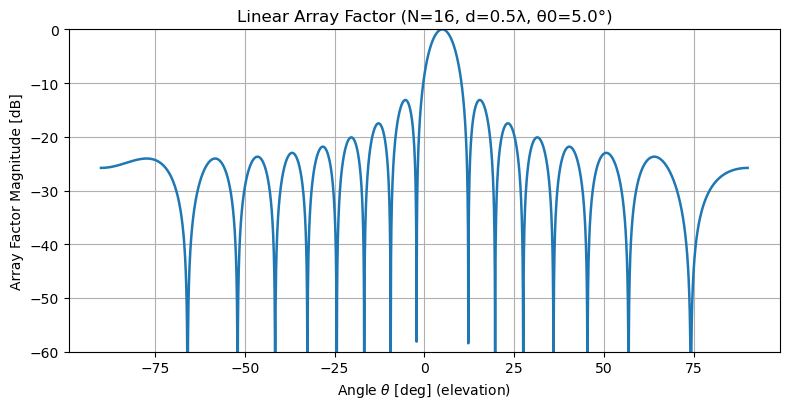

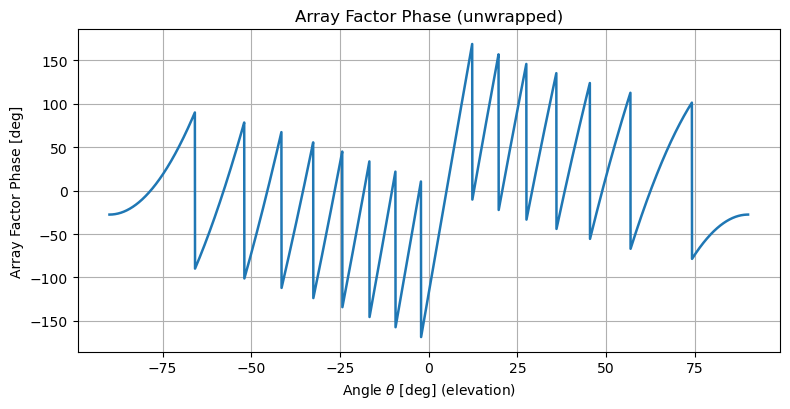

In [107]:
# === STEP2a: アンテナパターン（アレイファクタ）を可視化 ===
import numpy as np
import matplotlib.pyplot as plt

# 既存の array_factor_full があれば再定義しない
if 'array_factor_full' not in globals():
    def array_factor_full(theta_rad: float, N: int, d_lambda: float, theta0_rad: float) -> complex:
        """
        線形等間隔アレイ（等振幅・等位相励振）の複素アレイファクタ。
        F_full = exp(j*(N-1)u/2) * [ sin(Nu/2)/(N sin(u/2)) ], u = 2π(d/λ)(sinθ - sinθ0)
        """
        u = 2.0*np.pi*d_lambda * (np.sin(theta_rad) - np.sin(theta0_rad))
        # 恒等変形：np.sinc(x) = sin(πx)/(πx) なので引数を /π に
        num = np.sinc((N*u/2.0)/np.pi)    # = sin(Nu/2)/(Nu/2)
        den = np.sinc((u/2.0)/np.pi)      # = sin(u/2)/(u/2)
        amp = num / den                   # 実数の正規化振幅
        phi = 0.5*(N-1)*u                 # 線形位相
        return amp * np.exp(1j*phi)

# 既存パラメータを尊重（未定義なら安全な既定値を設定）
N          = N if 'N' in globals() else 16
d_lambda   = d_lambda if 'd_lambda' in globals() else 0.5
theta0_rad = theta0_rad if 'theta0_rad' in globals() else 0.0

# 角度軸（-90〜+90 deg）
theta_deg = np.linspace(-90.0, 90.0, 4001)
theta_rad = np.deg2rad(theta_deg)

# アレイファクタ計算
F = np.array([array_factor_full(th, N=N, d_lambda=d_lambda, theta0_rad=theta0_rad) for th in theta_rad])
mag_db = 20.0*np.log10(np.clip(np.abs(F), 1e-6, None))
phase_deg = np.degrees(np.unwrap(np.angle(F)))

# 振幅[dB]
plt.figure(figsize=(8, 4.2))
plt.plot(theta_deg, mag_db, lw=1.8)
plt.xlabel(r"Angle $\theta$ [deg] (elevation)")
plt.ylabel("Array Factor Magnitude [dB]")
plt.title(f"Linear Array Factor (N={N}, d={d_lambda}λ, θ0={np.rad2deg(theta0_rad):.1f}°)")
plt.ylim(-60, 0)
plt.grid(True)
plt.tight_layout()
plt.show()

# 位相[deg]
plt.figure(figsize=(8, 4.2))
plt.plot(theta_deg, phase_deg, lw=1.8)
plt.xlabel(r"Angle $\theta$ [deg] (elevation)")
plt.ylabel("Array Factor Phase [deg]")
plt.title("Array Factor Phase (unwrapped)")
plt.grid(True)
plt.tight_layout()
plt.show()


素子ごとに電界を計算して、合成して地面反射の影響を分析、最後に上の結果との比較　⇒　同じ結果になった。

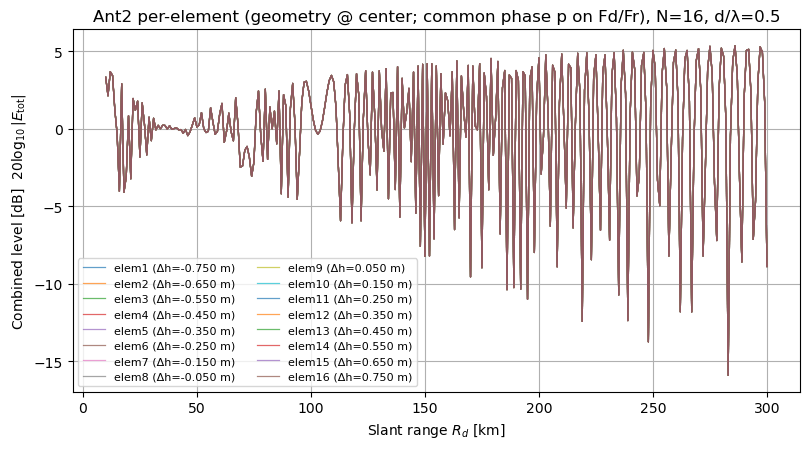

In [108]:
# === STEP-Z (修正版): 素子ごと（AFなし）Etotを返す＋素子位相pをFに掛ける ===
import numpy as np
import matplotlib.pyplot as plt

def compute_element_vs_range(h1_center, h2, *, offset_m=0.0,
                             eps_r=eps_r, sigma=sigma, freq=freq, pol=pol, a=a, k=k, Rd_m=Rd_m):
    """
    幾何は中心素子(h1_center)で固定。
    offset_m [m] は素子の高さオフセット。到来角(ed)に対し p = exp(+j·2π·(offset/λ)·sin(ed)) を作り、
    Fd, Fr に同じ p を掛ける（Fd-Fr の相対位相差は維持）。
    戻り値: {Etot, level_dB, ...}
    """
    lam = 3.0e8 / float(freq)

    deltaR_m = np.full_like(Rd_m, np.nan, dtype=float)
    psi_rad  = np.full_like(Rd_m, np.nan, dtype=float)
    eps_dir  = np.full_like(Rd_m, np.nan, dtype=float)
    eps_refl = np.full_like(Rd_m, np.nan, dtype=float)
    level_dB = np.full_like(Rd_m, np.nan, dtype=float)
    Etot_arr = np.full(Rd_m.shape, np.nan, dtype=np.complex128)

    for i, Rd in enumerate(Rd_m):
        # 幾何は中心素子で評価（← ここが重要：素子ごとの差は F の位相で入れる）
        geom = spherical_two_ray_lengths(h1=h1_center, h2=h2, Rd=Rd, a=a, k=k)
        if not np.isfinite(geom["deltaR"]):
            continue
        deltaR_m[i] = geom["deltaR"]
        ed, er = elevations_from_geometry(geom, h1_center, h2)   # ed/er は中心幾何での到来仰角
        psi = grazing_angle_from_geometry(geom, h1_center, h2)
        psi_rad[i]  = psi
        eps_dir[i], eps_refl[i] = ed, er

        # 素子の高さオフセットによる共通位相 p（直達到来角 ed を基準に）
        # ※ 符号が逆に見える場合は - を + に（またはその逆に）切り替えてください
        p = np.exp(+1j * 2.0*np.pi * (offset_m/lam) * np.sin(ed))

        # Fd/Fr に同じ p を掛ける（Fd−Fr の相対位相差は現状維持）
        Fd = p
        Fr = p

        Gm = fresnel_gamma(psi, eps_r=eps_r, sigma=sigma, f_hz=freq, pol=pol)
        out = combine_AF_and_gamma(deltaR=deltaR_m[i], f_hz=freq, F_dir=Fd, F_refl=Fr, gamma=Gm)
        level_dB[i] = out["level_dB"]
        Etot_arr[i] = out["Etot"]

    return {
        "Etot": Etot_arr,
        "level_dB": level_dB,
        "deltaR_m": deltaR_m, "psi_rad": psi_rad, "eps_dir": eps_dir, "eps_refl": eps_refl,
    }

# --- Ant2 の素子リスト（高さ方向に等間隔）---
lam = 3.0e8 / float(freq)
N2  = int(N)
center = (N2 - 1) / 2.0
h1_offsets_m = (np.arange(N2) - center) * (float(d_lambda) * lam)

ant2_elems = [
    {
        "offset_m": float(dh),
        "name": f"elem{i+1} (Δh={dh:.3f} m)"
    }
    for i, dh in enumerate(h1_offsets_m)
]

# --- 各素子 Etot を計算（幾何は中心 h1_2 で固定。素子位相は offset_m で付与）---
res_by_elem = {}
for i, el in enumerate(ant2_elems, start=1):
    res_by_elem[f"res{i}"] = compute_element_vs_range(h1_center=h1, h2=h2, offset_m=el["offset_m"])

# （任意）素子ごとのレベル確認
plt.figure(figsize=(8.2, 4.6))
for i, el in enumerate(ant2_elems, start=1):
    plt.plot(Rd_km, res_by_elem[f"res{i}"]["level_dB"], lw=0.9, alpha=0.7, label=el["name"])
plt.xlabel("Slant range $R_d$ [km]")
plt.ylabel(r"Combined level [dB]  $20\log_{10}|E_{\rm tot}|$")
plt.title(f"Ant2 per-element (geometry @ center; common phase p on Fd/Fr), N={N2}, d/λ={d_lambda}")
plt.grid(True); plt.legend(ncol=2, fontsize=8); plt.tight_layout(); plt.show()


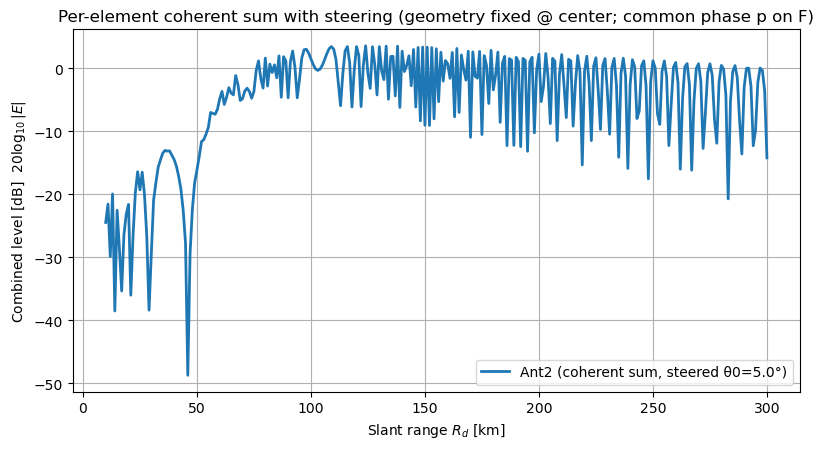

In [109]:
# === STEP-Z+ : ステアリングベクトルで合成（1/N 正規化） ===
import numpy as np
import matplotlib.pyplot as plt

# ステア角（Ant2 の θ0 を使用）
if 'theta0' in globals():
    theta0_rad_use = float(theta0)
elif 'theta0_rad' in globals():
    theta0_rad_use = float(theta0_rad)
else:
    theta0_rad_use = float(theta0_rad)

theta0_deg_use = np.degrees(theta0_rad_use)

# 素子インデックスとステアリング重み
N2 = int(N)
center = (N2 - 1) / 2.0
m = np.arange(N2) - center
d_over_lambda = float(d_lambda)

w = np.exp(-1j * 2.0*np.pi * d_over_lambda * m * np.sin(theta0_rad_use))  # array_factor_full と整合する符号

# 素子Etotを積む → 合成（1/N正規化）
Etot_stack = np.stack([res_by_elem[f"res{i}"]["Etot"] for i in range(1, N2+1)], axis=0)  # (N2, M)
E_array = (w @ Etot_stack) / N2

# 20log10|.| 表示
mag = np.maximum(np.abs(E_array), 1e-15)
level_db = 20.0 * np.log10(mag)

plt.figure(figsize=(8.2, 4.6))
plt.plot(Rd_km, level_db, lw=2.0, label=f"Ant2 (coherent sum, steered θ0={theta0_deg_use:.1f}°)")
plt.xlabel("Slant range $R_d$ [km]")
plt.ylabel(r"Combined level [dB]  $20\log_{10}|E|$")
plt.title("Per-element coherent sum with steering (geometry fixed @ center; common phase p on F)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


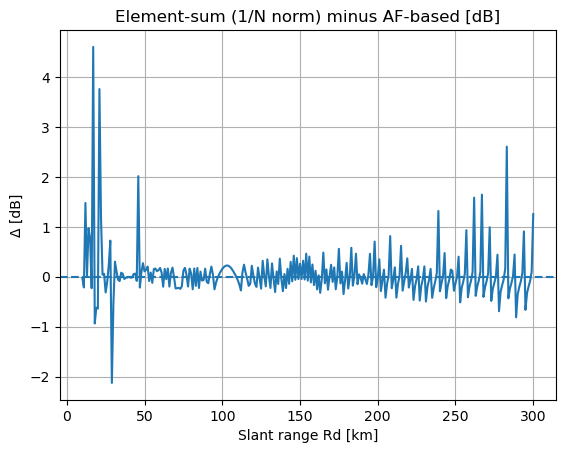

In [110]:
# AF 法（従来）
res_AF = level_dB
# 素子合成（上の E_array を使用）
diff_db = level_db - res_AF
plt.figure(); plt.plot(Rd_km, diff_db); plt.axhline(0, ls="--")
plt.title("Element-sum (1/N norm) minus AF-based [dB]")
plt.xlabel("Slant range Rd [km]"); plt.ylabel("Δ [dB]"); plt.grid(True); plt.show()


In [ ]:
end